In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
df = pd.read_csv('2025-01.csv', skiprows=[1,2])
df.head()

,sasdate,GDPC1,PCECC96,PCDGx,PCESVx,PCNDx,GPDIC1,FPIx,Y033RC1Q027SBEAx,PNFIx,...,TNWMVBSNNCBBDIx,TLBSNNBx,TLBSNNBBDIx,TABSNNBx,TNWBSNNBx,TNWBSNNBBDIx,CNCFx,S&P 500,S&P div yield,S&P PE ratio
0,3/1/1959,3352.129,2039.017,68.6651,1374.1739,689.1172,354.894,357.0174,47.8021,171.0783,...,1341.67,333245.24,266668.11,2426352.41,2092.54,1674.48,124.9663,55.5167,3.1765,18.6211
1,6/1/1959,3427.667,2070.508,71.2495,1394.7096,694.8197,382.500,368.0640,49.2332,176.0004,...,1294.15,345845.01,273329.36,2434975.21,2088.55,1650.63,126.5305,57.5067,3.1012,19.2899
2,9/1/1959,3430.057,2092.138,72.6270,1413.6627,697.4699,357.798,371.9585,50.8372,180.7406,...,1320.72,354808.05,275139.48,2434604.03,2079.21,1612.34,128.9557,58.7300,3.0720,18.9544
3,12/1/1959,3439.832,2094.495,69.1573,1430.8157,701.7617,369.442,367.6452,50.7342,180.2333,...,1165.65,349400.81,254967.79,2429055.21,2079.05,1517.14,137.0372,57.7633,3.1572,17.8221
4,3/1/1960,3517.181,2114.532,71.3815,1443.7405,703.5338,406.581,379.9162,52.4985,186.4967,...,1327.63,362821.95,278692.55,2451394.44,2087.97,1603.82,130.1872,56.2767,3.3850,16.8284


In [94]:
# Data Preprocessing
# Convert date column to datetime format
df.rename(columns={df.columns[0]: "Date"}, inplace=True)
df["Date"] = pd.to_datetime(df["Date"])

# Compute key variables
df["t_spread"] = df["GS10"] - df["FEDFUNDS"]
df["corpyield_spread"] = df["BAA"] - df["AAA"]

# Select relevant variables
variables = [
    "ACOGNOx", "PERMIT", "UMCSENTx", "CLAIMSx", "OPHMFG", "OPHNFB", "OPHPBS", "S&P 500", "t_spread", "corpyield_spread", "GDPC1"
]

df_selected = df[["Date"] + variables].dropna()

# Compute quarterly growth rates for all variables EXCEPT GDP
rate_variables = [var for var in variables if var != "GDPC1"]  # Exclude GDP
df_selected[[f"{var}_Rate" for var in rate_variables]] = df_selected[rate_variables].pct_change() * 100  

# Compute annualized GDP growth rate separately
df_selected["GDPC1_Rate"] = 400 * np.log(df_selected["GDPC1"] / df_selected["GDPC1"].shift(1))

# Drop rows with NaN values (first row after pct_change() and shift())
df_selected = df_selected.dropna()

# Identify recession periods (one quarter of negative GDP growth)
df_selected["Recession"] = df_selected["GDPC1_Rate"] < 0

             ACOGNOx       PERMIT    UMCSENTx       CLAIMSx      OPHMFG  \
count     130.000000   130.000000  130.000000  1.300000e+02  130.000000   
mean   183205.638172  1374.553848   85.778462  3.693338e+05   85.872954   
std     25000.861152   401.239008   13.202748  2.472100e+05   17.400546   
min    139796.778600   538.666700   56.100000  2.070670e+05   51.435000   
25%    160444.937575  1130.750000   76.150000  2.840708e+05   70.642250   
50%    186638.546250  1413.500000   89.100000  3.336830e+05   94.911000   
75%    202133.856950  1644.166650   94.450000  3.789502e+05  100.018500   
max    227672.912900  2228.333300  110.100000  2.775633e+06  103.552000   

           OPHNFB      OPHPBS      S&P 500    t_spread  corpyield_spread  \
count  130.000000  130.000000   130.000000  130.000000        130.000000   
mean    87.109446   87.062562  1754.863615    1.413642          0.944203   
std     16.221782   16.385867  1195.852887    1.316048          0.370883   
min     61.570000   

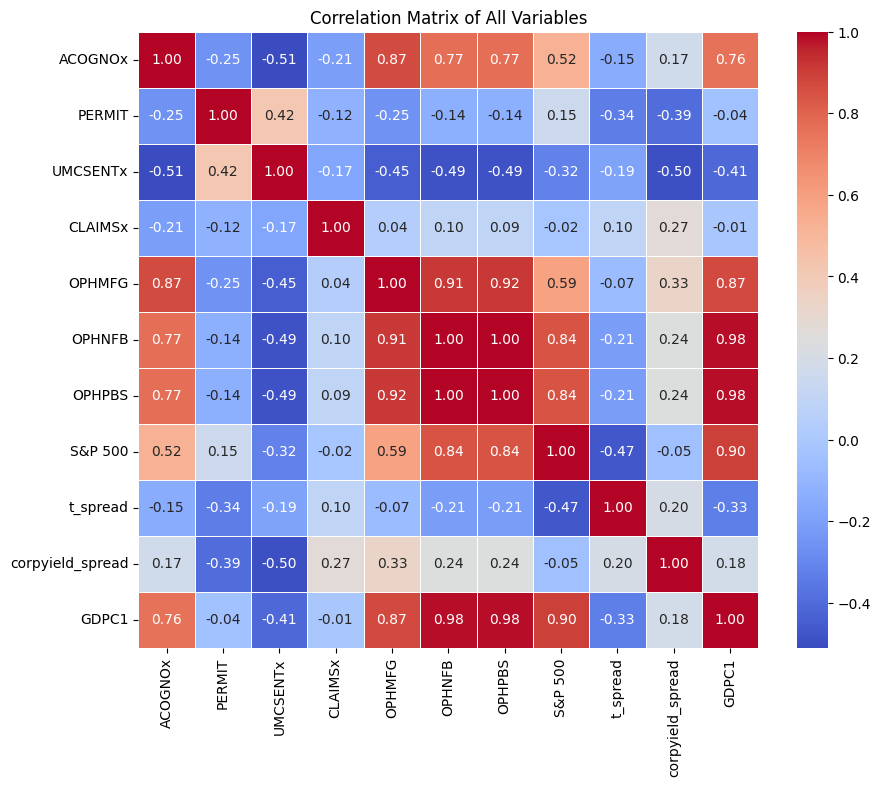

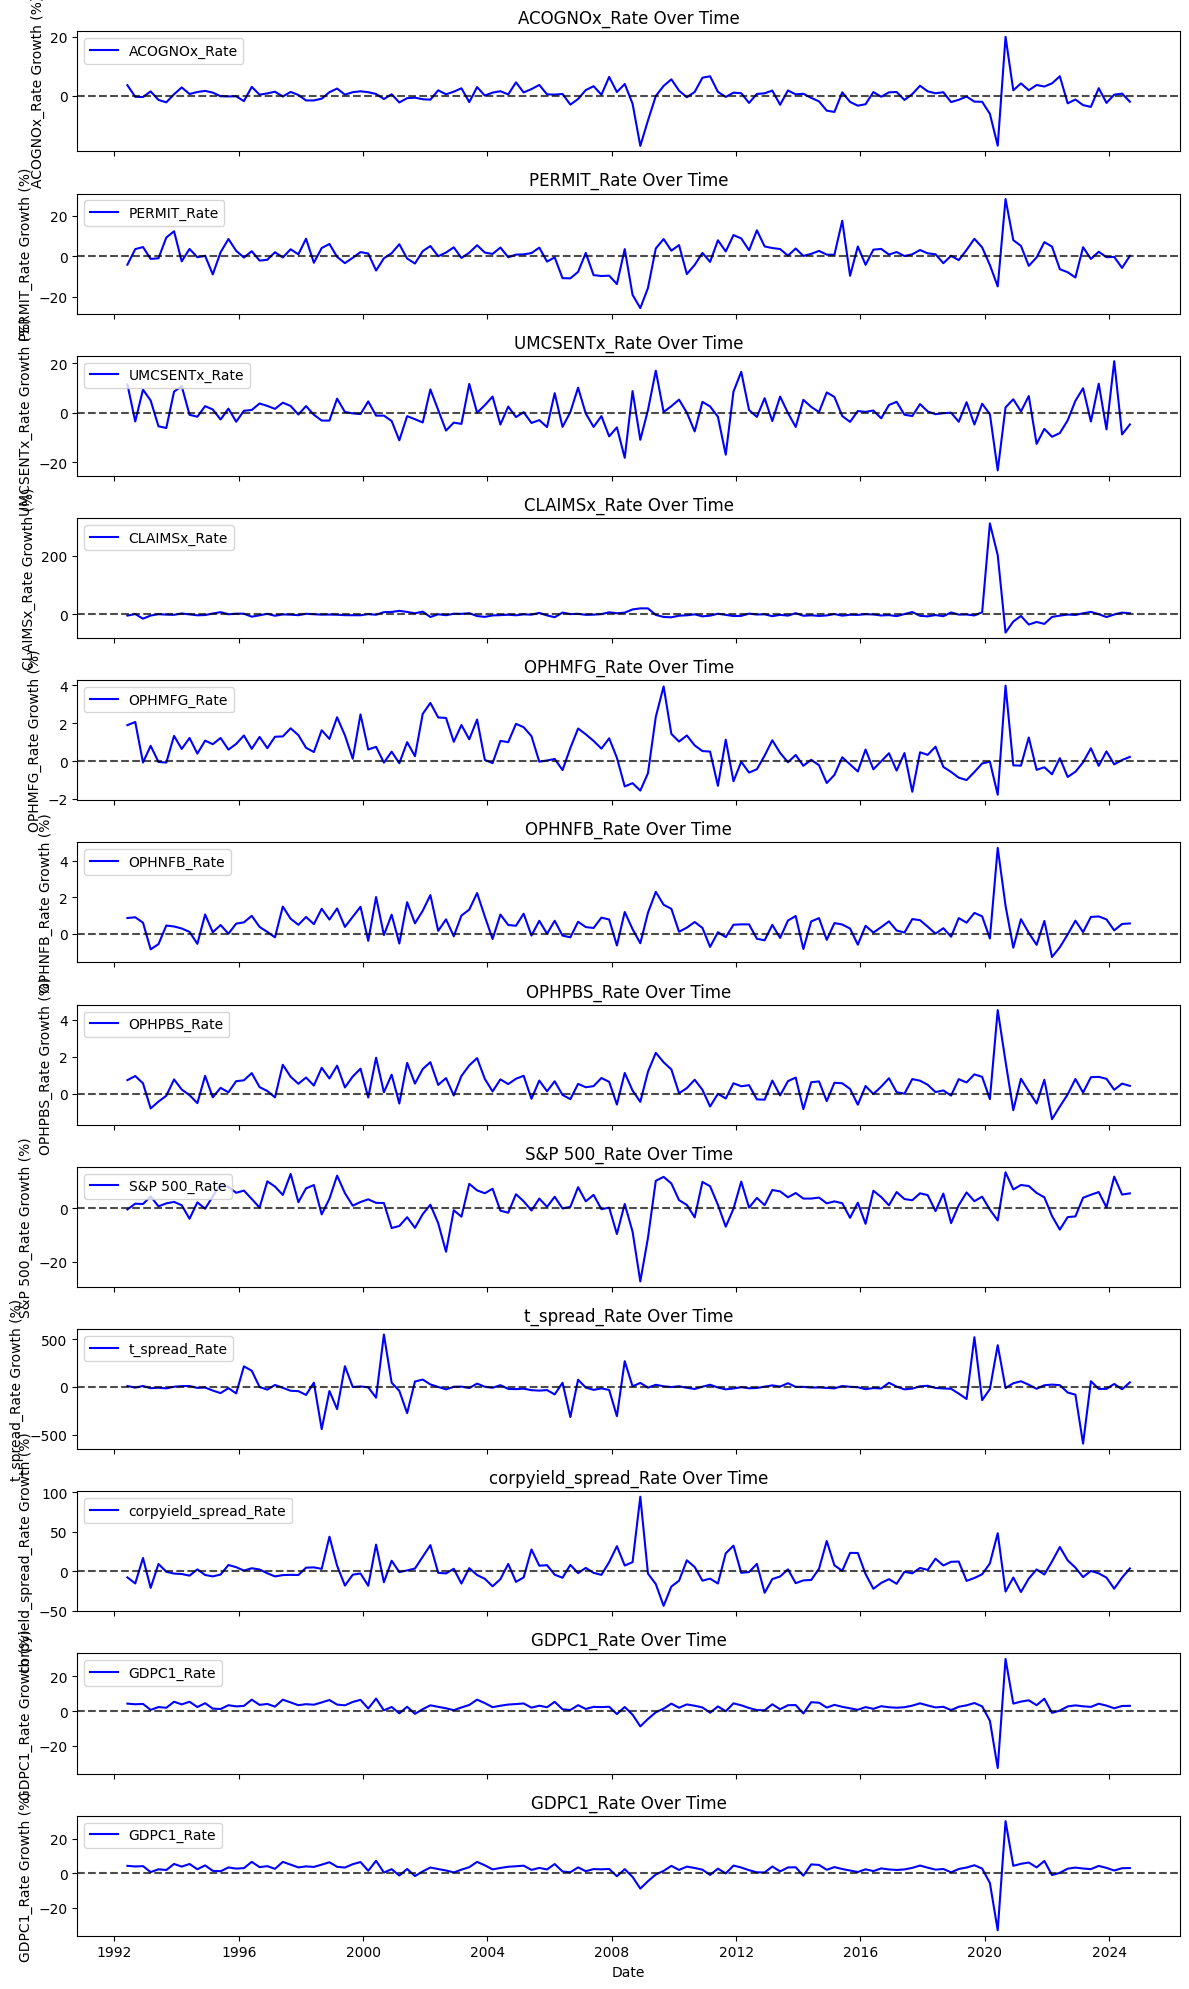

Total recession quarters: 13
Recession periods:
168   2001-03-01
170   2001-09-01
196   2008-03-01
198   2008-09-01
199   2008-12-01
200   2009-03-01
201   2009-06-01
208   2011-03-01
210   2011-09-01
220   2014-03-01
244   2020-03-01
245   2020-06-01
252   2022-03-01
Name: Date, dtype: datetime64[ns]


In [ ]:
# Exploratory Data Analysis
# Summary statistics for raw values
summary_stats = df_selected[variables].describe()
print(summary_stats)

# Summary statistics for growth rates
growth_variables = [f"{var}_Rate" for var in variables if var in df_selected.columns] + ["GDPC1_Rate"]
growth_summary_stats = df_selected[growth_variables].describe()
print(growth_summary_stats)

# Compute correlation between all selected variables
full_corr_matrix = df_selected[variables].corr()

# Plot heatmap for full correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(full_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of All Variables")
plt.show()


# Plot growth rates over time
fig, axes = plt.subplots(nrows=len(growth_variables), figsize=(12, 20), sharex=True)

for i, var in enumerate(growth_variables):
    ax = axes[i]
    ax.plot(df_selected["Date"], df_selected[var], label=var, color="blue")
    ax.axhline(y=0, color="black", linestyle="--", alpha=0.7)  # Zero growth line
    ax.set_ylabel(f"{var} Growth (%)")
    ax.set_title(f"{var} Over Time")
    ax.legend(loc="upper left")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

# Count number of recession quarters
num_recession_quarters = df_selected["Recession"].sum()
print(f"Total recession quarters: {num_recession_quarters}")

# Find recession start and end dates
recession_periods = df_selected[df_selected["Recession"]]["Date"]
print("Recession periods:")
print(recession_periods)


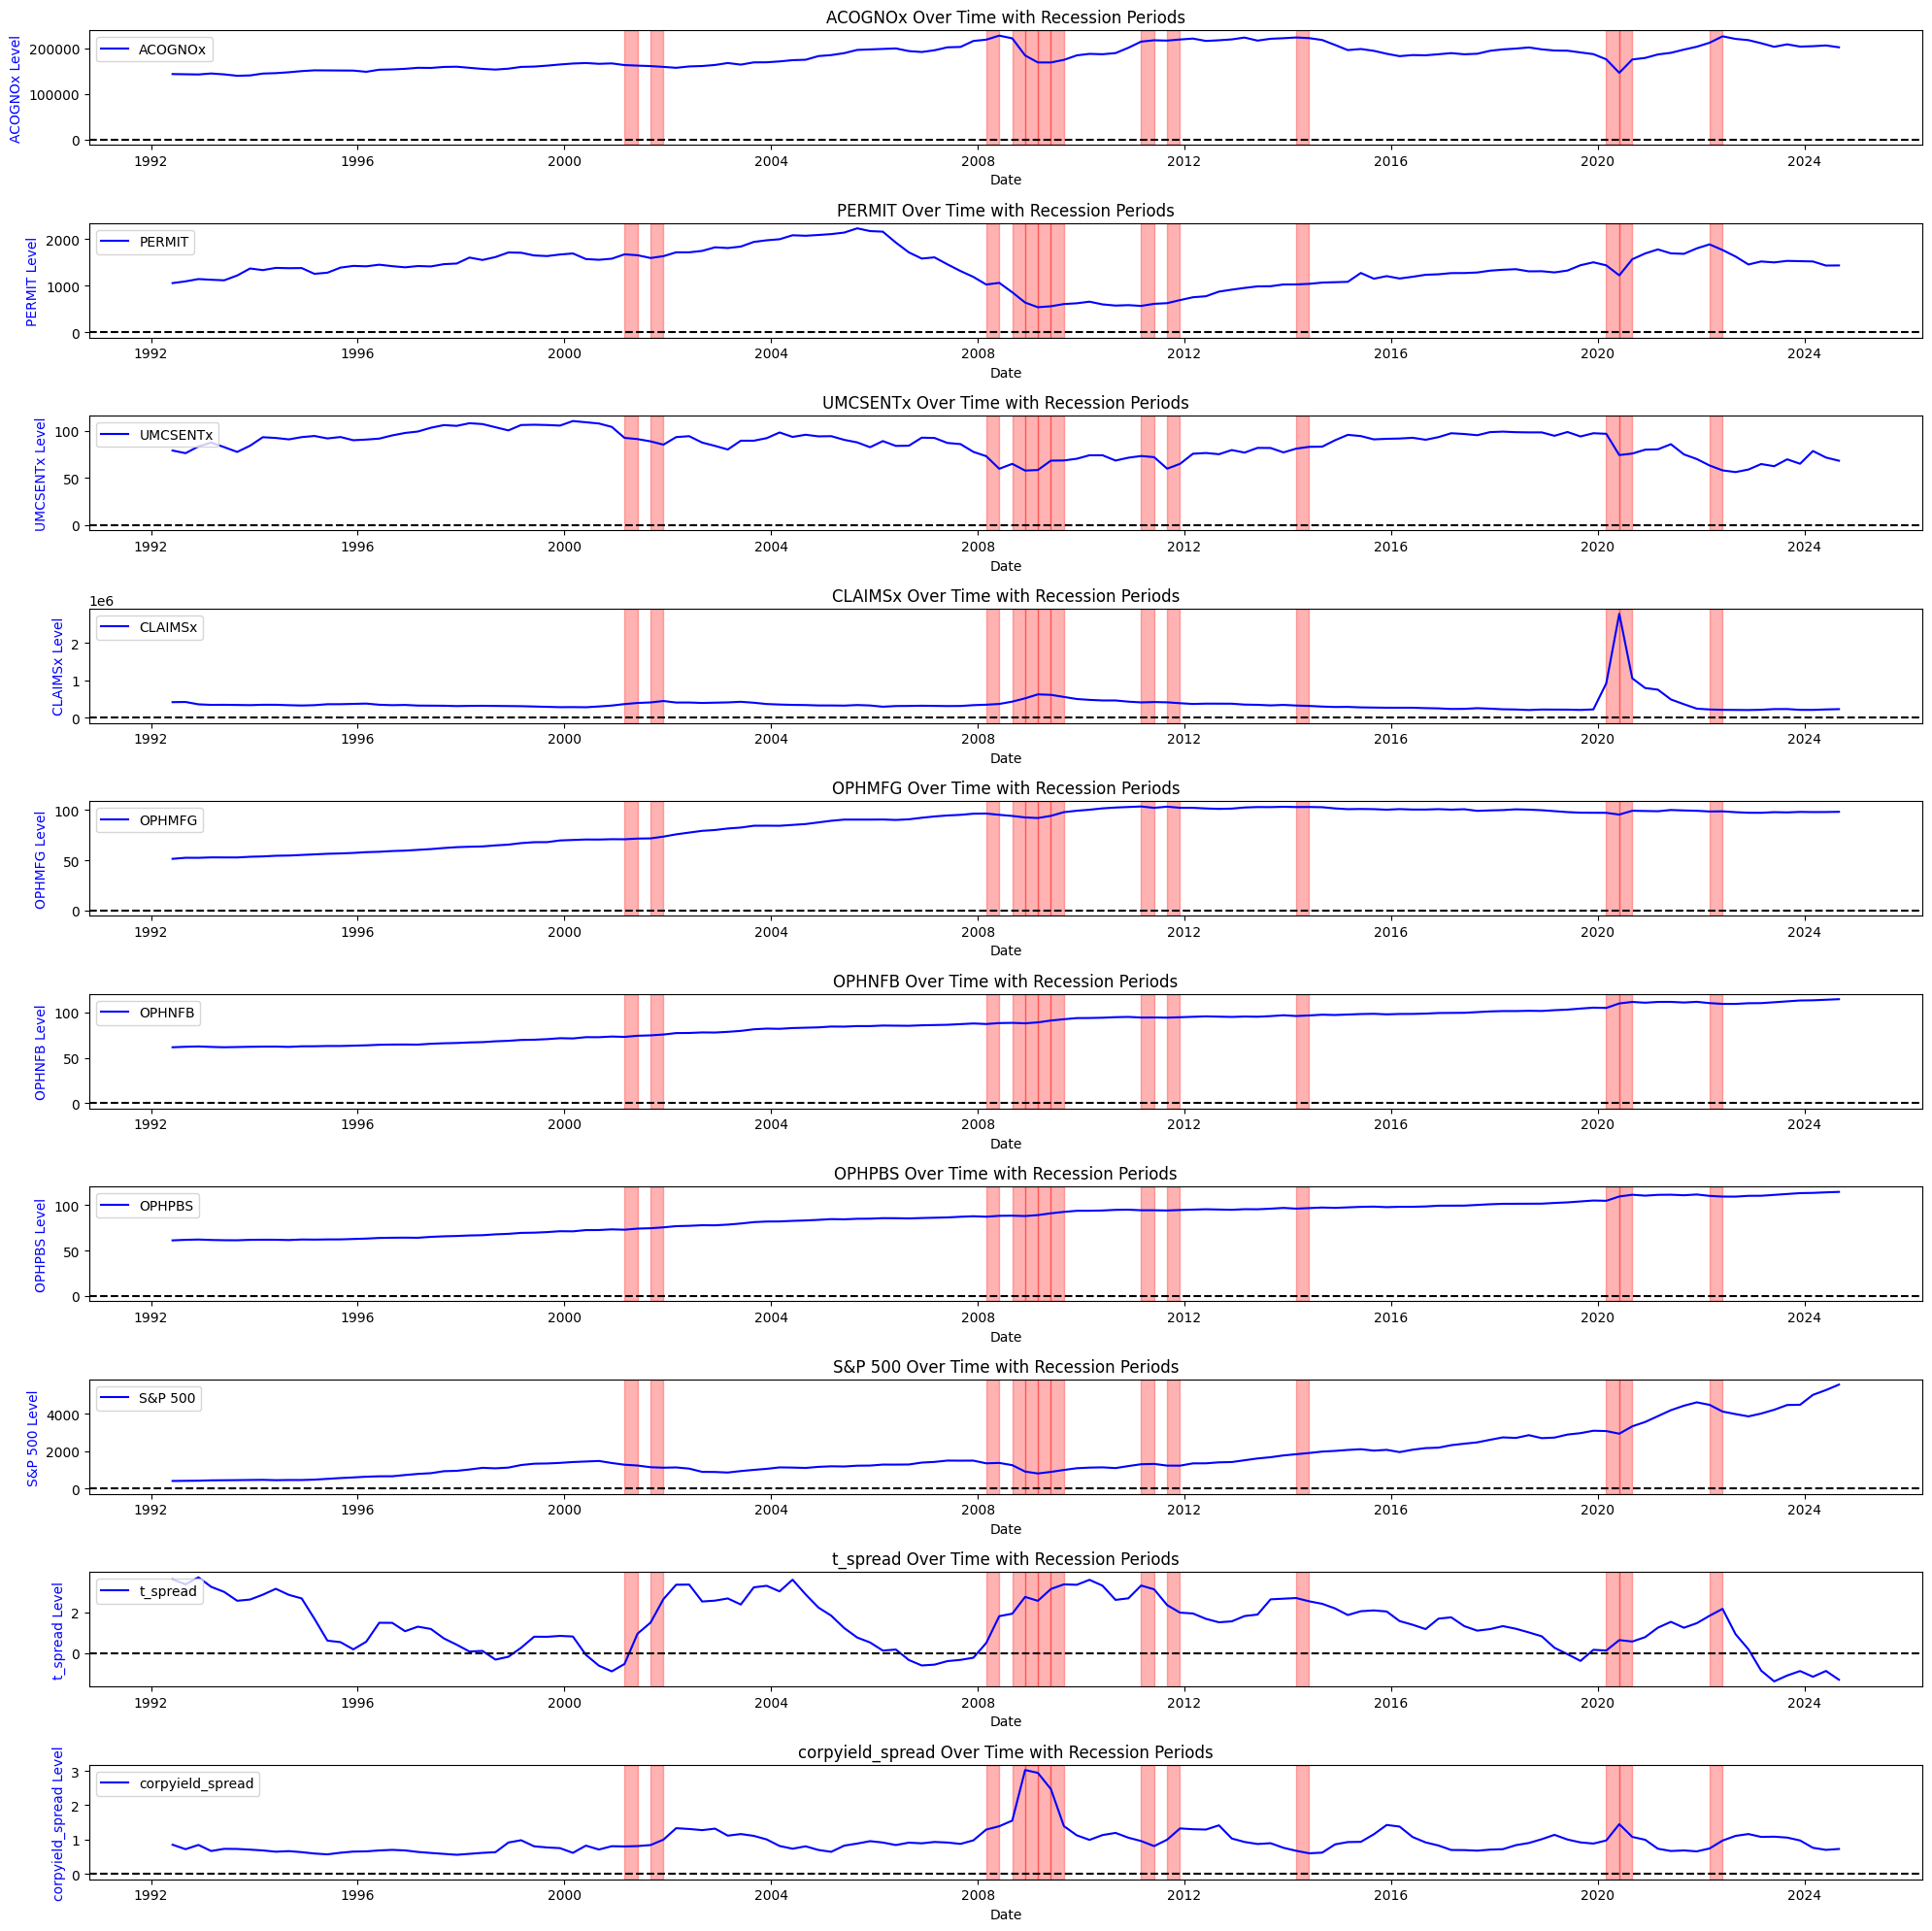

In [96]:
# Variable Levels vs GDP Growth with Highlighted Contractions ###
fig, axes = plt.subplots(nrows=10, figsize=(20, 20))
axes = axes.flatten()

for i, var in enumerate(variables[:-1]):  # Exclude GDP itself
    ax = axes[i]
    ax.plot(df_selected["Date"], df_selected[var], label=var, color="blue")
    ax.set_ylabel(f"{var} Level", color="blue")
    ax.set_xlabel("Date")
    ax.axhline(y=0, color="black", linestyle="--")  # Add horizontal line at 0
    ax.set_title(f"{var} Over Time with Recession Periods")

    # Highlight recession periods
    for j in range(len(df_selected) - 1):
        if df_selected["Recession"].iloc[j]:
            ax.axvspan(df_selected["Date"].iloc[j], df_selected["Date"].iloc[j + 1], color="red", alpha=0.3)

    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

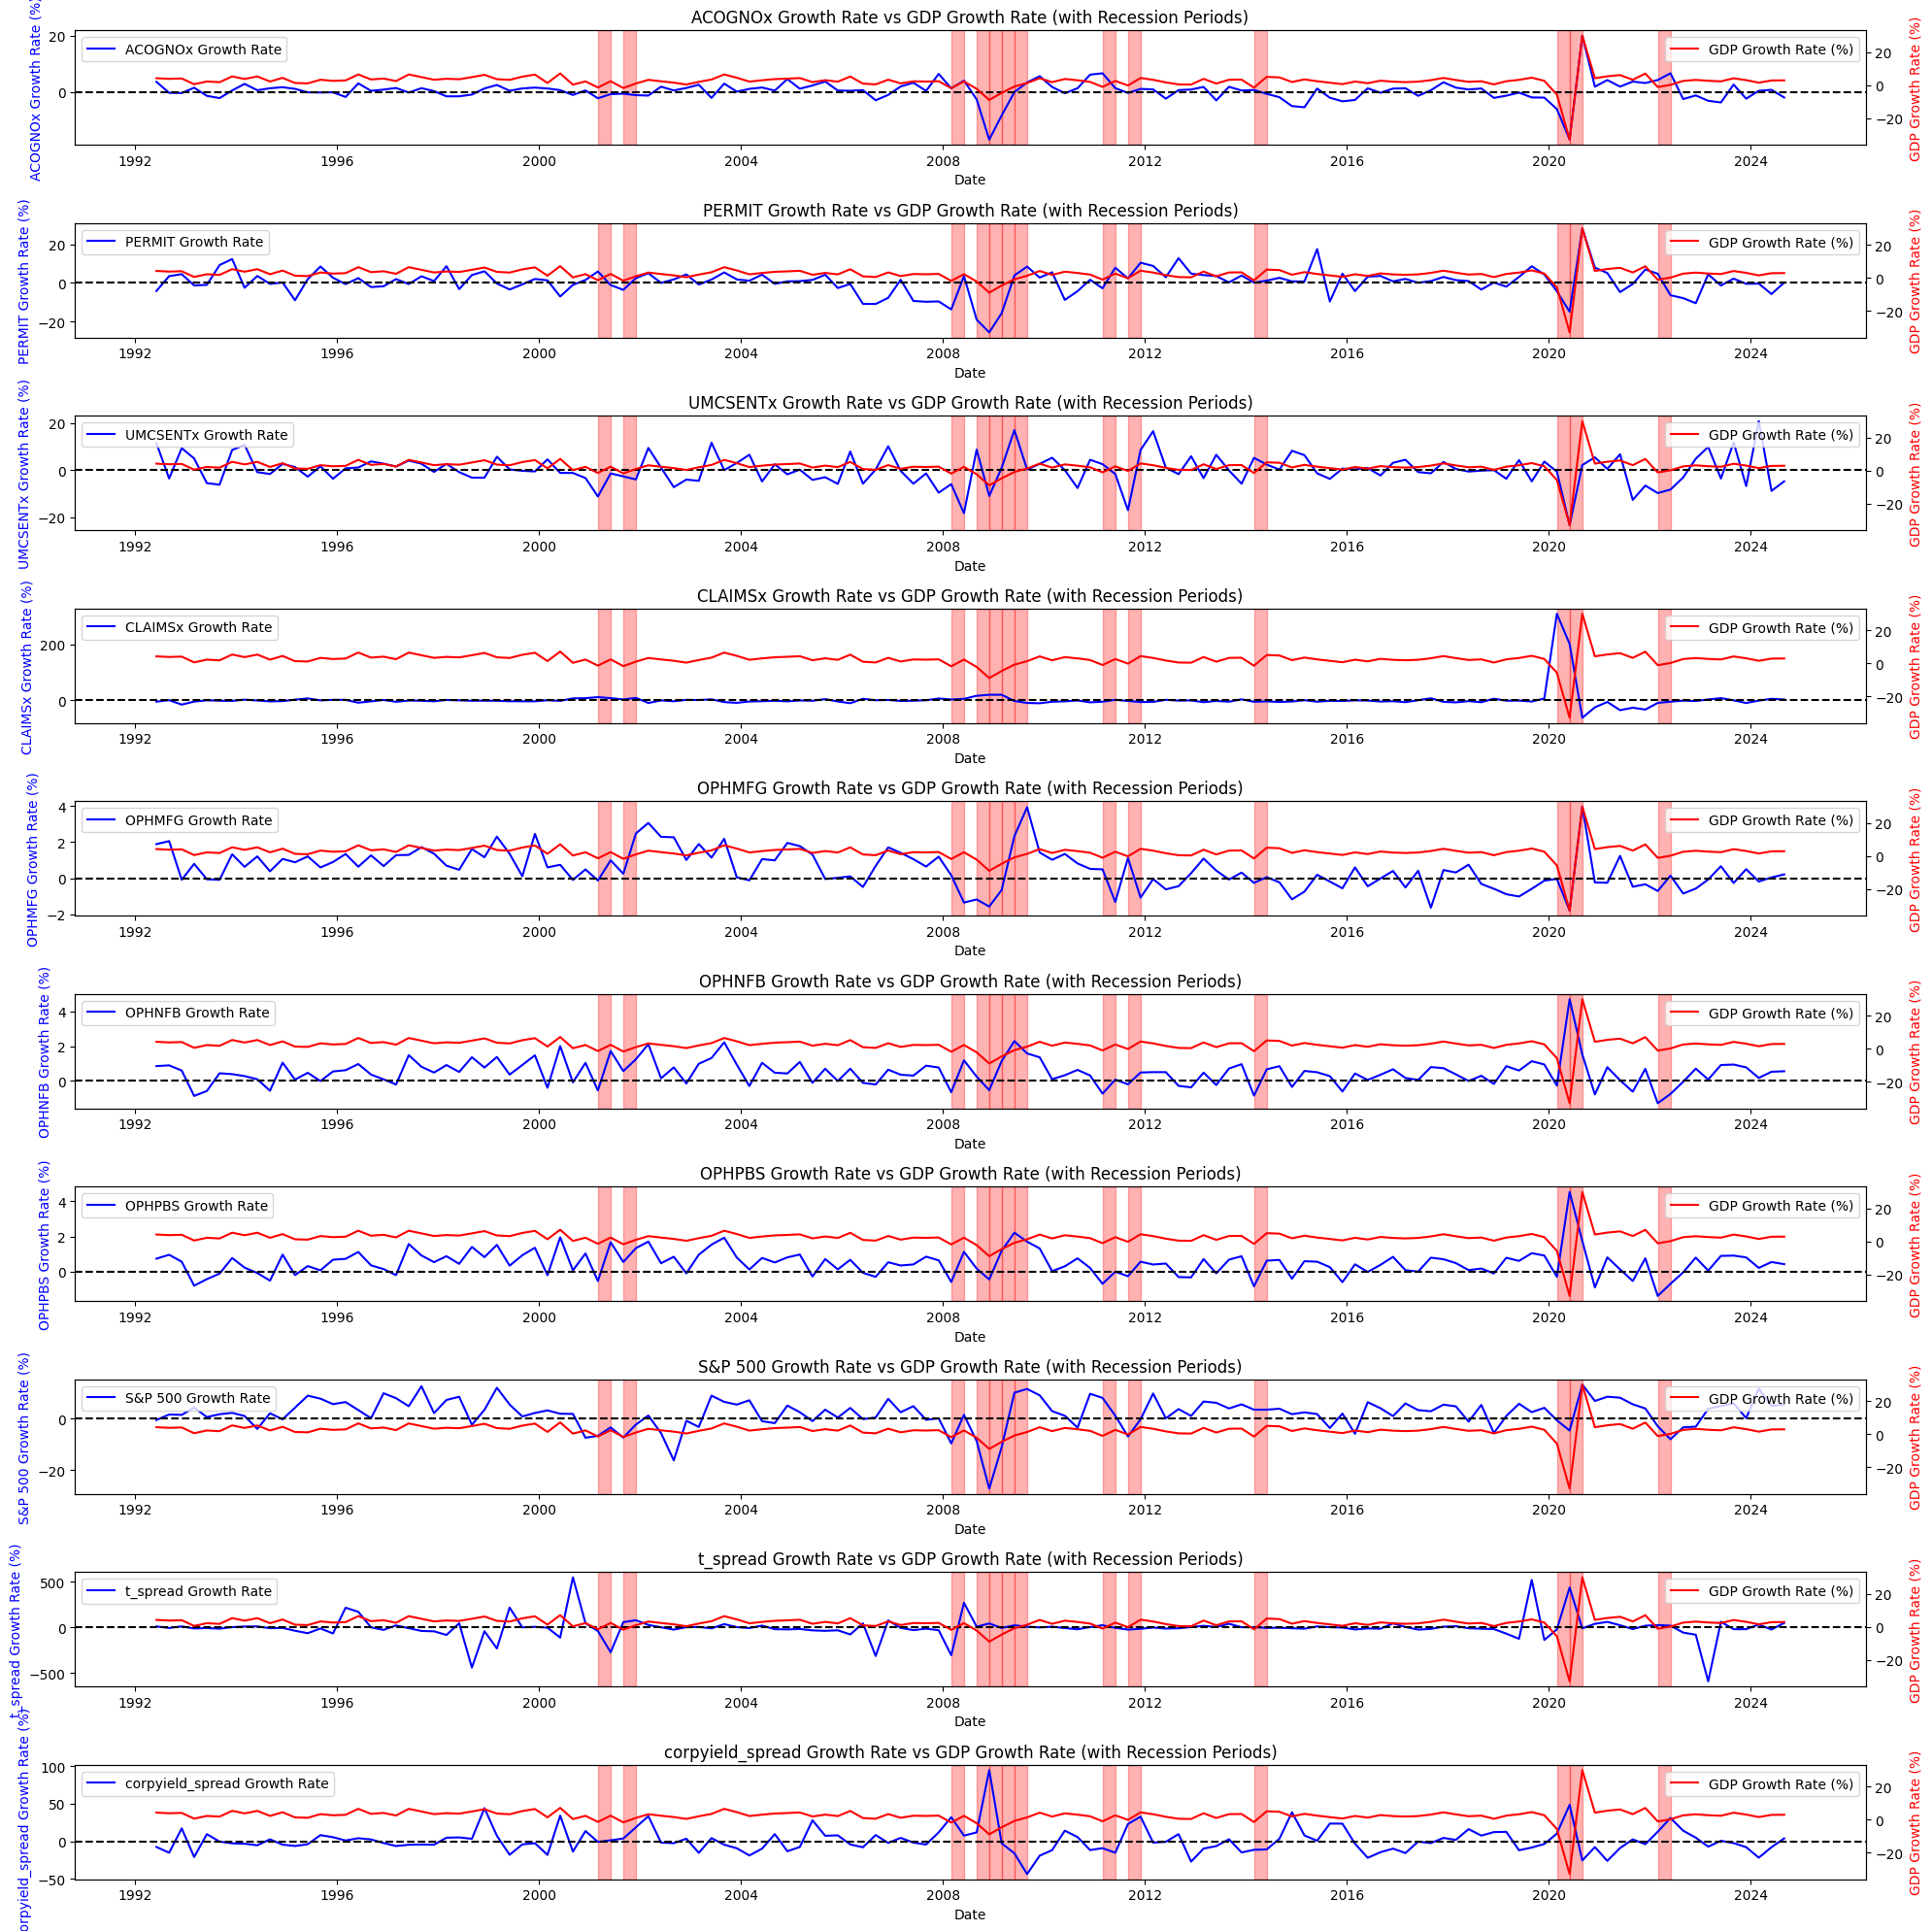

In [97]:
# Variable Growth vs GDP Growth with Highlighted Contractions ###
rate_variables = [f"{var}_Rate" for var in variables[:-1]]  # Exclude GDP itself

fig, axes = plt.subplots(nrows=10, figsize=(20, 20))
axes = axes.flatten()

for i, var in enumerate(rate_variables):
    ax = axes[i]
    ax.plot(df_selected["Date"], df_selected[var], label=var.replace("_Rate", " Growth Rate"), color="blue")
    ax.set_ylabel(f"{var.replace('_Rate', '')} Growth Rate (%)", color="blue")
    ax.set_xlabel("Date")
    ax.axhline(y=0, color="black", linestyle="--")  # Add horizontal line at 0

    # Plot GDP growth rate on secondary axis
    ax2 = ax.twinx()
    ax2.plot(df_selected["Date"], df_selected["GDPC1_Rate"], label="GDP Growth Rate (%)", color="red")
    ax2.set_ylabel("GDP Growth Rate (%)", color="red")

    # Highlight recession periods
    for j in range(len(df_selected) - 1):
        if df_selected["Recession"].iloc[j]:
            ax.axvspan(df_selected["Date"].iloc[j], df_selected["Date"].iloc[j + 1], color="red", alpha=0.3)

    ax.set_title(f"{var.replace('_Rate', '')} Growth Rate vs GDP Growth Rate (with Recession Periods)")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()
